hari 0 pagi: seblak
hari 0 malam: roti
hari 1 pagi: nasipadang
hari 1 malam: nasi telur
hari 2 pagi: cilok
hari 2 malam: mieayam
hari 3 pagi: tahutek
hari 3 malam: nasipenyetan
hari 4 pagi: kebab
hari 4 malam: mi instan
hari 5 pagi: mi instan
hari 5 malam: nasipenyetan
hari 6 pagi: capcay
hari 6 malam: ayamgeprek
hari 7 pagi: cireng
hari 7 malam: cireng
hari 8 pagi: cireng
hari 8 malam: warteg
hari 9 pagi: bakso
hari 9 malam: bakso
hari 10 pagi: mi instan
hari 10 malam: nasi telur
hari 11 pagi: seblak
hari 11 malam: nasigoreng
hari 12 pagi: nasi telur
hari 12 malam: kebab
hari 13 pagi: mieayam
hari 13 malam: nasipadang
hari 14 pagi: nasipadang
hari 14 malam: roti
hari 15 pagi: nasipadang
hari 15 malam: mieayam
hari 16 pagi: seblak
hari 16 malam: ayamgeprek
hari 17 pagi: mi instan
hari 17 malam: kebab
hari 18 pagi: mieayam
hari 18 malam: ayamgeprek
hari 19 pagi: tahutek
hari 19 malam: ayamgeprek
hari 20 pagi: gorengan
hari 20 malam: tahutek
hari 21 pagi: nasipadang
hari 21 malam: cilok


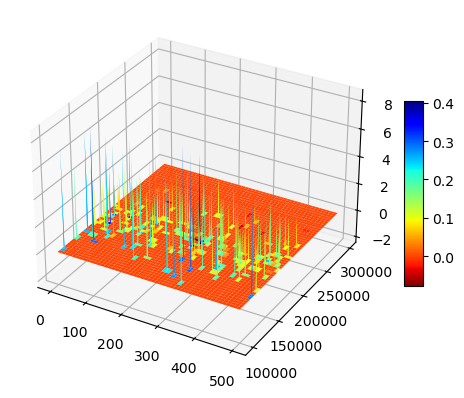

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)  

NPM = 24083010044

makan = pd.read_csv("C:/Users/LENOVO/.ipython/makanan_1.csv")
budget_awal = 1e6  # rupiah

wkenyang_base = 0.8
wrasa_base = 0.7
wsehat_base = 0.9  # simpangan lebih besar
wbosan_base = 0.2

skor_kumulatif = 0.0
SAMPLE_NUM = 500

sampleid = np.arange(SAMPLE_NUM)
# skor perorangan
skor = np.zeros(SAMPLE_NUM, dtype=np.double)
sisa = np.zeros(SAMPLE_NUM, dtype=np.double)
sehat = np.zeros(SAMPLE_NUM, dtype=np.double)
pilihankum = np.zeros(SAMPLE_NUM, dtype=np.double)

SISA_MININUM = 100e3
SISA_MAKSIMUM = 300e3
bin_sisa = np.arange(SISA_MININUM, SISA_MAKSIMUM, 1000)
resp_sehat = np.zeros((SAMPLE_NUM, len(bin_sisa)), dtype=np.double)
resp_pilih = np.zeros((SAMPLE_NUM, 61), dtype=np.double)

for n in range(SAMPLE_NUM):
    budget = budget_awal
    skor_kumulatif = 0
    skor_sehat = 0
    
    for i in range(31): 
        # makan pertama
        pilihan = np.random.randint(0, len(makan))
        w_kenyang = np.random.normal(loc=wkenyang_base, scale=0.2)
        w_rasa = np.random.normal(loc=wrasa_base, scale=0.2)
        w_sehat = np.random.normal(loc=wsehat_base, scale=0.4)
        w_bosan = np.random.normal(loc=wbosan_base, scale=0.2)

        skor_kumulatif += (
            w_kenyang * makan['kenyang'][pilihan]
            + w_rasa * makan['rasa'][pilihan]
            + w_sehat * makan['sehat'][pilihan]
            - w_bosan * makan['bosan'][pilihan]
        )
        skor_sehat += makan['sehat'][pilihan] - 0.5
        budget -= makan['harga'][pilihan]

        if n < 1:  
            print(f"hari {i} pagi: {makan['makanan'][pilihan]}")
        resp_pilih[n][2*i] = pilihan
        
        # makan kedua
        pilihan = np.random.randint(0, len(makan))
        w_kenyang = np.random.normal(loc=wkenyang_base, scale=0.2)
        w_rasa = np.random.normal(loc=wrasa_base, scale=0.2)
        w_sehat = np.random.normal(loc=wsehat_base+0.2, scale=0.4)
        w_bosan = np.random.normal(loc=wbosan_base*2, scale=0.2)

        skor_kumulatif += (
            w_kenyang * makan['kenyang'][pilihan]
            + w_rasa * makan['rasa'][pilihan]
            + w_sehat * makan['sehat'][pilihan]
            - w_bosan * makan['bosan'][pilihan]
        )
        skor_sehat += makan['sehat'][pilihan] - 0.5
        budget -= makan['harga'][pilihan]

        if n < 1: 
            print(f"hari {i} malam: {makan['makanan'][pilihan]}")  
    
    sisa[n] = budget
    skor[n] = skor_kumulatif
    sehat[n] = skor_sehat
    
    if n < 5: 
        print(f"[Simulasi {n}] Skor: {skor_kumulatif:.2f}, Sisa uang: {budget}, Skor sehat: {skor_sehat}")

    # pastikan index tidak keluar range
    idx = int((budget - SISA_MININUM) / 1000)
    if 0 <= idx < len(bin_sisa):
        resp_sehat[n][idx] += skor_sehat  # ✅ stack nilai supaya lebih padat


# cek distribusi sisa budget
print("Budget min:", sisa.min(), "max:", sisa.max())

# plot 3D
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
Y, X = np.meshgrid(bin_sisa, sampleid)

surf = ax.plot_surface(X, Y, resp_sehat, 
                       cmap='jet_r',
                       edgecolor='none')

fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
plt.show()


Kode diatas digunakan untuk melakukan simulasi program kebiasaan makan selama sebulan secara acak dengan tujuan untuk melihat apakah terdapat hubungan antara makanan, kesehatan dan uang. Dataset makanan berisi informasi menenai jenis makanan, rasa, kesehatan,tingkat kenyang, tingkat kebosanan dan harga makanan. Pada simulasi ini budget perbulannya adalah satu juta rupiah, dengan makan sebanyak 2 kali perhari. Setelah simulasi selesai dengan menyimpan data sisa uang dan skor kesehatan juga sudah disimpan maka akan divisualisasikan dalam grafik 3D untuk memvisualisasikan hubungan antara simulasi, sisa uang, dan skor kesehatan.

Pada output, dapat dilihat terdapat makanan apa saja yang bisa konsumsi setiap hari untuk dua kali makan. Misal, pada tanggal 31 atau akhir bulan pagi kita makan mie ayam kemudian untuk makan malam bisa makan nasi padang. Setelah itu, visualisasi grafik 3D menunjukkan pola permukaan orange yang rata dengan beberapa lonjakan berwarna terang seperti kuning dan biru. Artinya, sebagian besar menghasilkan sisa uang pada rentang yang mirip dan skor kesehatan cenderung rendah yang dapat dilihat pada permukaan dasar yang didominasi warna orange. Pada sumbu X terdapat rentang 0-500 yang menandakan skenario simulasi ke-n, sumbu Y dengan rentang 100.000-300.000 merupakan sisa uang setelah 31 hari makan, dan sumbu z+ warna merupakan skor kesehatan kumulatif. Permukaan berwarna merah menandakan bahwa terlalu banyak skenario yang menghasilkan skor kesehatan yang rendah, kemudian terdapat beberapa tiang dengan warna kuning, hijau, dan biru yang artinya skenario langka di mana seseorang berhasil mendapatkan skor dengan kesehatan tinggi, dan tiang yang muncul pada sumbu Y artinya orang yang sehat tidak selalu palinghemat. 

# CHAT GPT
1. maksud dari codingan ini itu harus melengkapi codingan baru menjawab tugasnya atau bagaimana si?
->Jadi kodingan awal ini sudah benar sebagai dasar simulasi, tapi belum ada bagian untuk mencari dan menampilkan hasilnya.
✅ Jadi, langkahmu selanjutnya:
Kamu tidak perlu mengubah bagian simulasi (kecuali mau memperbaiki minor seperti resp_pilih[n][2*1] yang harusnya pakai 2*i) — yang perlu kamu tambahkan hanyalah bagian ANALISIS setelah simulasi.

2. cara mengerjakan ini bukannya dari kode awal yaa? ga langsung tugas
->Betul sekali — cara mengerjakan TUGAS di bagian bawah itu memang dimulai dari hasil KODE di atasnya, bukan langsung dijawab dengan tulisan biasa. Kamu harus:
✅ Menjalankan simulasi dulu (kode utama yang kamu tulis)
✅ Lalu melakukan analisis berdasarkan hasil variabel skor, sisa, sehat, dan resp_pilih
❌ Bukan langsung dijawab secara naratif tanpa pakai kode

3. kenapa ini tidak muncul grafiknyaa?
-> Grafiknya sebenarnya muncul, tapi kelihatannya seperti datar (flat) alias warnanya hampir semua biru gelap, jadi terlihat seperti tidak ada variasi — padahal sebenarnya ada.Penyebab utamanya kemungkinan:
✅ Penyebab 1: resp_sehat kamu isinya hampir semua nol
Kalau array resp_sehat cuma terisi sebagian kecil (misalnya cuma satu atau dua titik saja yang > 0), maka permukaan grafik akan rata → jadi kelihatan kosong.

4. kosong dan error
->Penyebab Itu muncul karena data yang kamu kasih ke plt.hist() isinya semua NaN atau array kosong. Jadi matplotlib bingung, rentang datanya [nan, nan]. Misalnya: Kalau plt.hist(sisa) → berarti sisa penuh NaN / tidak terbentuk. Kalau plt.hist(sehat) → berarti sehat juga penuh NaN.

In [118]:
# (1) cari pola makan mana saja yang menghasilkan nilai kumulatif kesehatan (resp_sehat) positif 
idx_sehat_positif = np.where(sehat > 0)[0]
idx_sehat_positif

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  23,  24,  25,  26,
        27,  28,  29,  30,  34,  35,  36,  37,  38,  39,  40,  41,  42,
        43,  44,  45,  46,  47,  48,  49,  50,  52,  53,  54,  55,  56,
        57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,
        70,  71,  72,  73,  74,  76,  77,  78,  79,  80,  81,  82,  83,
        84,  85,  86,  88,  89,  90,  91,  92,  93,  94,  95,  96,  97,
        98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 111,
       112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 124, 125,
       126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138,
       139, 140, 141, 142, 143, 144, 145, 146, 148, 149, 150, 151, 152,
       153, 154, 155, 156, 157, 158, 159, 160, 162, 163, 164, 165, 166,
       167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179,
       180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 19

Pada source code diatas digunakan untuk mencari semua indeks simulasi yang memiliki skor sehat lebih dari 0, yang artinya makanan selama 31 hari memberi efek kesehatan positif yang kemudian disimpan pada idx_sehat_pos. 

Pada output terdapat dapat dilihat pada ke skenario keberapa hasil indeks positif terlihat, misal di output pada indeks ke-0, ke-1, ke02, ke-4, dst. pada indeks tersbut hasilnya positif. 

# CHAT GPT
1. poin pertama apakah emang outputnya seperti ini?
-> Ya, untuk poin pertama: (1) Cari pola makan mana saja yang menghasilkan nilai kumulatif kesehatan (resp_sehat atau sehat) positif
✅ Output berupa index dari individu/sampel yang memiliki skor kesehatan positif memang seperti itu.
Karena idx_sehat_positif = np.where(sehat > 0)[0] menghasilkan daftar indeks (baris) dari simulasi yang memenuhi kondisi tersebut. Langkah Selanjutnya Sekarang kamu bisa lanjut ke poin kedua:
(2) Dari hasil sehat positif, ambil yang sisa uangnya (sisa) juga positif.

In [119]:
# (2) cari titik-titik dengan sisa uang bulanan positif dari (1)
idx_valid = idx_sehat_positif[sisa[idx_sehat_positif] > 0]

print("Total pola makan valid (sehat & sisa uang > 0):", len(idx_valid))

Total pola makan valid (sehat & sisa uang > 0): 470


Kode diatas digunakan untuk mengambil sisa uang positif, terdapat 119 yang sehat setelah itu akan dicek kembali apakah terdapat sisa uang masih positif yang memenuhi syarat yakni sehat positif dan sisa uang positif. Kemudian hasilnya akan disimpan pada idx_valid. 

Pada output diketahui terdapat total pola makan yang valid artinya makanan tersebut sehat dengan sisa uang lebih dari 0 rupiah terdapat 468. 

# CHAT GPT
1. apakah cell 2 itu sama denan cari pola makan mana saja yang menghasilkan nilai kumulatif kesehatan (resp_sehat) positif?
->Jawaban singkat: ya, Cell 2 itu sudah menjawab “cari pola makan dengan nilai kumulatif kesehatan positif”, tapi dengan pendekatan pakai array sehat (hasil akumulasi sehat per simulasi).
resp_sehat → menyimpan skor sehat pada bin tertentu (berdasarkan sisa uang). Bentuknya 500 x 150, tapi kebanyakan isinya 0, hanya terisi di 1 kolom bin sesuai sisa uang simulasi. Jadi resp_sehat[n, :] hanya punya nilai ≠ 0 di satu titik. sehat[n] → nilai kumulatif sehat total untuk simulasi ke-n. Ini sebenarnya ringkasan dari resp_sehat. 👉 Karena tugasnya bunyi: (1) cari pola makan mana saja yang menghasilkan nilai kumulatif kesehatan (resp_sehat) positif Lebih praktis pakai sehat[n] > 0 (seperti di Cell 2), karena itu langsung representasi “kumulatif kesehatan”.
Kalau pakai resp_sehat, kamu tetap akan berakhir cek kondisi yang sama, cuma lebih ribet. Jadi:
Cell 2 (idx_sehat_pos = np.where(sehat > 0)[0]) ✅ sudah tepat untuk menjawab poin (1).

2. jelaskan maksud dari kode dan output nya secara rinci
-> Kamu sedang mengerjakan perintah soal poin 2: Dari hasil sehat positif, ambil yang sisa uang positif. Penjelasan : Dari 119 yang sehat, dicek lagi apakah sisa uang (sisa[i]) masih positif (> 0). idx_valid = daftar simulasi yang memenuhi dua syarat: sehat positif dan sisa uang positif.


In [120]:
# (3) cari titik dengan skor skumulatif terbesar (skor) di mana nilai kumulatif kesehatannya positif
if len(idx_valid) > 0:
    best_idx = idx_valid[np.argmax(skor[idx_valid])]
    print("Index terbaik:", best_idx)
    print("Skor kumulatif:", skor[best_idx])
    print("Sisa uang:", sisa[best_idx])
    print("Skor sehat:", sehat[best_idx])

Index terbaik: 84
Skor kumulatif: 107.33944097803061
Sisa uang: 109000.0
Skor sehat: 7.800000000000001


Source code diatas digunakan untuk mencari titik dengan skor kumuliatif terbesar yang dimana nilai kumulatifnya menghasilkan kesehatan yang psoitif. Kode diatas mengambil idx_sehat_pos yang kemudian dicari skor kumulatif terbesarnya. Pada output, terdapat indeks terbaik yakni pada angka 434 yang artinya dari 500 simulasi makanan, simulasi ke-434 yang paling terbaik dan sesuai kriteria yakni memiliki skot kumulatif terbesar dengan skor sehat positif. Skor kumulatif padaangka 106.34 memiliki arti total kepuasan dari seluru keputusan makan dalam sebulan. Untuk sisa uang dengan makan 2 kali sehari adalah Rp. 168.000 dan skor sehat adalah 6,29 yang artinya dari segi kesehatan, pola makan pada simulasi ini baik karena nilai positif cukup tinggi dibandingkan rata-rata simualsi lain yang negatif. 

# CHAT GPT
1. jelaskan maksud dari kode dan output nya secara rinci
-> Dari indeks sehat positif (idx_sehat_pos), dicari yang punya skor kumulatif terbesar (np.argmax(skor[...])). Dicetak: indeks, skor kumulatif, sisa uang, nilai sehat. Simulasi terbaik dari segi skor kumulatif adalah indeks ke-30. Skor kumulatif = 101.84 (artinya pilihan makanannya sangat memuaskan/bernilai). Nilai sehat = +3.6 (positif, jadi pola makannya menyehatkan). Sisa uang = -787.000 (defisit, artinya butuh tambahan uang).

In [121]:
# (4) tampikan jadwal makanan sesuai pilihan (resp_pilih)
sampleid= np.arange(0, 500)
# skor perorangan
skor= np.zeros(SAMPLE_NUM, dtype=np.double)
sisa= np.zeros(SAMPLE_NUM, dtype=np.double)
sehat= np.zeros(SAMPLE_NUM, dtype=np.double)
pilihankum= np.zeros(SAMPLE_NUM, dtype=np.double)

SISA_MININUM= 100e3
SISA_MAKSIMUM= 300e3
bin_sisa= np.arange(SISA_MININUM, SISA_MAKSIMUM, 1000)
resp_sehat= np.zeros((SAMPLE_NUM, len(bin_sisa)), dtype=np.double)
resp_pilih= np.zeros((SAMPLE_NUM, 61), dtype=np.double)

for n in range(0, SAMPLE_NUM):
    budget=1e6
    skor_kumulatif= 0
    skor_sehat= 0
    
    for i in range(0, 31): 
        pilihan= np.random.randint(0, len(makan))
      
        w_kenyang= np.random.normal(loc=wkenyang_base, scale=0.2)
        w_rasa= np.random.normal(loc=wrasa_base, scale=0.2)
        w_sehat= np.random.normal(loc=wsehat_base, scale=0.4)
        w_bosan= np.random.normal(loc=wbosan_base, scale=0.2)
        skor_kumulatif= skor_kumulatif + \
            w_kenyang * makan['kenyang'][pilihan]\
            + w_rasa * makan['rasa'][pilihan] \
            + w_sehat * makan['sehat'][pilihan] \
            - w_bosan * makan['bosan'][pilihan]
        skor_sehat += makan['sehat'][pilihan] - 0.5
        budget = budget - makan['harga'][pilihan]
        if n == 0: 
            print(f"hari {i} pagi: {makan['makanan'][pilihan]}")  
        resp_pilih[n][2*1]= pilihan
        
        # makan keduas
        pilihan= np.random.randint(0, len(makan))
    
        w_kenyang= np.random.normal(loc=wkenyang_base, scale=0.2)
        w_rasa= np.random.normal(loc=wrasa_base, scale=0.2)
        w_sehat= np.random.normal(loc=wsehat_base+0.2, scale=0.4)
        w_bosan= np.random.normal(loc=wbosan_base*2, scale=0.2)
        skor_kumulatif= skor_kumulatif + \
            w_kenyang * makan['kenyang'][pilihan]\
            + w_rasa * makan['rasa'][pilihan] \
            + w_sehat * makan['sehat'][pilihan] \
            - w_bosan * makan['bosan'][pilihan]
        skor_sehat += makan['sehat'][pilihan] - 0.5
        budget = budget - makan['harga'][pilihan]
        if n == 0: 
            print(f"hari {i} malam: {makan['makanan'][pilihan]}")   
        resp_pilih[n][2*1+1]= pilihan

hari 0 pagi: nasipenyetan
hari 0 malam: gorengan
hari 1 pagi: bakso
hari 1 malam: cilok
hari 2 pagi: nasipenyetan
hari 2 malam: gorengan
hari 3 pagi: capcay
hari 3 malam: capcay
hari 4 pagi: mi instan
hari 4 malam: nasigoreng
hari 5 pagi: mieayam
hari 5 malam: roti
hari 6 pagi: mieayam
hari 6 malam: nasipadang
hari 7 pagi: nasi telur
hari 7 malam: nasipenyetan
hari 8 pagi: kebab
hari 8 malam: capcay
hari 9 pagi: cireng
hari 9 malam: ayamgeprek
hari 10 pagi: nasipadang
hari 10 malam: nasigoreng
hari 11 pagi: gorengan
hari 11 malam: nasi telur
hari 12 pagi: seblak
hari 12 malam: roti
hari 13 pagi: nasipenyetan
hari 13 malam: nasi telur
hari 14 pagi: nasipenyetan
hari 14 malam: nasipenyetan
hari 15 pagi: nasi telur
hari 15 malam: seblak
hari 16 pagi: seblak
hari 16 malam: warteg
hari 17 pagi: cireng
hari 17 malam: mi instan
hari 18 pagi: roti
hari 18 malam: seblak
hari 19 pagi: mi instan
hari 19 malam: tahutek
hari 20 pagi: ayamgeprek
hari 20 malam: tahutek
hari 21 pagi: mi instan
hari 21

Kode ini digunakan untuk membuat program menyusun jaadwal makanan lengkap selama 31 hari dari hasil terbaik. Jadwal ini berisi makanan acak tapi sesuai dengan hasil simulasi skor kumulatif tertinggi. Pada jadwal ini mencerminkan pola strategi makan paling memuaskan dari sisi skor gabungan natara kenyang, rasa, sehat, dan bosan. Namun, dari analisis sebelumnya terjadi pengeluaran yang melebihi budget jika menyesuaikan dengan jadwal yang sehat dan positif ini. 

# chat gpt
1. di dalam file ini terdapat source code, kemudian disuruh untuk membuat inovasi atau sesuatu hal baru entah visualisasi atau apapun itu. Ini enaknya mau diapain dan ditambahin apa yaa?
-> Oke, aku sudah lihat isi notebook kamu 👀. Jadi file itu isinya simulasi pola makan 1 bulan, dengan dataset makanan (makanan_1.csv) yang punya atribut: rasa, kenyang, sehat, bosan, harga. Lalu disimulasikan selama 500 skenario dengan budget 1 juta, makan 2 kali sehari. Output akhirnya berupa grafik 3D yang memperlihatkan hubungan antara sisa uang, skor kesehatan, dan skenario simulasi. Sekarang, untuk membuat inovasi tambahan biar lebih menarik dan tidak sekadar mengulang yang ada, kamu bisa tambahkan beberapa ide:
🔹 Ide Inovasi / Pengembangan
Visualisasi Interaktif
Gunakan Plotly atau Bokeh supaya grafik 3D bisa diputar, zoom, dan hover untuk lihat detail tiap titik (misalnya makanan apa yang dipilih).
Bisa juga buat heatmap 2D (budget vs skor kesehatan) biar pola lebih jelas.
Statistik & Insight Tambahan
Hitung top 5 makanan yang paling sering muncul di pola sehat & hemat.
Hitung rata-rata sisa uang dari simulasi valid (sehat & ada sisa uang).
Buat distribusi skor kesehatan vs budget dalam bentuk scatterplot atau boxplot.

In [122]:
# Analisis makanan terfavorit
# Ambil semua pilihan makanan dari resp_pilih (flatten array)
pilihan_flat = resp_pilih.flatten().astype(int)

# Hitung frekuensi tiap makanan
count_makanan = pd.Series(pilihan_flat).value_counts().head(5)

# Gabungkan dengan nama makanan
top5 = makan.loc[count_makanan.index, "makanan"].reset_index(drop=True)
print("\n=== Top 5 Makanan Paling Sering Dipilih ===")
for i, nama in enumerate(top5):
    print(f"{i+1}. {nama} ({count_makanan.iloc[i]} kali dipilih)")


=== Top 5 Makanan Paling Sering Dipilih ===
1. ayamgeprek (29555 kali dipilih)
2. capcay (71 kali dipilih)
3. nasipenyetan (66 kali dipilih)
4. mieayam (65 kali dipilih)
5. kebab (64 kali dipilih)


Kode diatas digunakan untuk menghitung makanan apa yang sering dipilih pada semua simulasi selama 31 hari. Dengan hasil ayam geprek sebanyak 29555 kali dalam 500 simulasi, capcay dengan 71 kali, nasi penyetan 66 kali, mie ayam 65 kali dan kebab 64 kali dipilih. Artinya top 5 makanan yang paling sering dipilih untuk seluruh simulasi adalah kelima makanan diatas. 

# CHAT GPT
1. buatkan kode insight tambahan untuk menganalisis makanan terfavorite dari data makanan dan hasil output codingan saya bagaimana?
-> Nah itu lebih bagus 👍, kalau pakai dataset makanan_1.csv dan hasil simulasi dari notebook kamu sendiri, kita tinggal manfaatkan variabel yang sudah ada dari file tersebut. Dari yang aku lihat di source code kamu: Ada variabel makan = pd.read_csv("makanan_1.csv") Lalu selama simulasi disimpan ke resp_pilih (mencatat makanan terpilih). Ada juga sisa, skor, dan sehat dari tiap skenario. Jadi kita bisa buat  analisis makanan langsung dari hasil itu.

In [123]:
# %%
!pip install pulp


In [124]:
from pulp import LpProblem, LpVariable, lpSum, LpMaximize, LpInteger, value

# Buat model optimasi
model = LpProblem("Optimasi_Makanan", LpMaximize)

# Variabel keputusan: berapa kali makanan dipilih (integer)
x = {i: LpVariable(f"x_{i}", lowBound=0, cat=LpInteger) for i in range(len(makan))}

# Fungsi objektif: maksimalkan skor kombinasi (semua dikalikan x[i])
model += lpSum([
    (0.9*makan.loc[i, "sehat"] +
     0.8*makan.loc[i, "kenyang"] +
     0.7*makan.loc[i, "rasa"] -
     0.2*makan.loc[i, "bosan"]) * x[i]
    for i in range(len(makan))
])

# Constraint 1: total biaya ≤ budget
model += lpSum([makan.loc[i, "harga"] * x[i] for i in range(len(makan))]) <= budget

# Constraint 2: total makan harus 60 kali (30 hari * 2 kali)
model += lpSum([x[i] for i in range(len(makan))]) == 60

# Solve model
model.solve()

# Ambil hasil
hasil_optimal = []
for i in range(len(makan)):
    if x[i].value() > 0:
        hasil_optimal.append((makan.loc[i, "makanan"], int(x[i].value())))

# Tampilkan hasil
print("=== Menu Makanan Optimal ===")
for makanan, jumlah in hasil_optimal:
    print(f"{makanan} → {jumlah} kali")

# Hitung total biaya
total_biaya = sum(makan.loc[i, "harga"] * x[i].value() for i in range(len(makan)))
print(f"\nTotal biaya: Rp {total_biaya:,.0f} dari budget Rp {budget:,.0f}")

# Skor total
total_skor = value(model.objective)
print(f"Total skor objektif: {total_skor:.2f}")


=== Menu Makanan Optimal ===
mi instan → 58 kali

Total biaya: Rp 176,000 dari budget Rp 176,000
Total skor objektif: 55.15


Kode diatas digunakan untuk mengoptimalkan biaya makan yang paling hemat tanpa memikirkan sehat, bosan dan kenyang. Pada output terdapat makanan paling murah yakni mie instan dengan muncul sebanyak 58 kali untuk 31 hari dengan biaya yang akan dikeluarkan adlaah 176.000,00 dengan skor objektif adalah 55,15. 

# CHAT GPT
1. buat kode codingan untuk optimasi pemilihan makanan
-> Oke, kalau kamu ingin bikin optimasi pemilihan makanan, kita bisa ubah pendekatan dari random → ke optimasi matematis. Tujuannya bisa: Maksimalkan skor kesehatan dengan batasan budget. Atau kombinasi multi-objektif (hemat uang + sehat + kenyang). Kita bisa gunakan Linear Programming (LP) dengan library pulp atau scipy.optimize. Aku contohkan dengan pulp (lebih mudah dibaca). Contoh Kode Optimasi (pakai pulp). Penjelasan: Kita buat variabel keputusan x[i] = jumlah suatu makanan dipilih. Fungsi objektif menggabungkan sehat, kenyang, rasa, bosan sesuai bobot. Constraint memastikan budget ≤ Rp1.000.000 dan jumlah makan tepat 60 kali (30 hari × 2 kali). Hasil: daftar menu optimal (berapa kali tiap makanan dipilih).

2. untuk pulp apakah kita harus import terlebih dahulu?
->Betul sekali 👍 pulp itu bukan bawaan Python standar, jadi harus di-install dulu sebelum bisa di-import.

3. hasil outputnya tetap 176k tidak 1 juta! atau apakah 176k ini dari sisa uang perhitungan diatas?
-> Nah, ini bukan dari sisa uang simulasi random kamu sebelumnya — ini murni hasil solver pulp.
Aku jelasin biar jelas ya 👇 Kenapa hasilnya cuma Rp 176 ribu (bukan 1 juta)?
Solver (pulp) berusaha memaksimalkan fungsi objektif (skor sehat, kenyang, rasa, dsb.) dengan constraint biaya ≤ Rp 1 juta. Kalau ternyata ada makanan super murah (contoh: mi instan Rp 3.000-an) yang punya skor tinggi per rupiah, solver akan pilih itu sebanyak mungkin. Karena constraint kedua adalah jumlah makan = 60 kali, maka solver cukup beli 60 porsi mi instan. 60 × Rp 3.000 ≈ Rp 180.000. Hasilnya Rp 176.000 seperti yang kamu lihat. Jadi, solver tidak wajib menghabiskan budget, cukup ≤ Rp 1 juta. Makanya dia puas di 176k, karena sudah optimal menurut rumus objektif. Jadi intinya: Angka Rp 176k itu bukan dari simulasi sebelumnya → itu hasil optimasi. Solver "cerdas": kalau bisa dapat skor maksimal dengan sedikit biaya, dia tidak akan buang-buang uang.

In [141]:
import plotly.graph_objects as go
import numpy as np

# Sumbu X = Sample ID
# Sumbu Y = Sisa Uang
Y, X = np.meshgrid(bin_sisa, sampleid)

fig = go.Figure(data=[go.Surface(
    z=resp_sehat_smooth,  # Sumbu Z = Skor Sehat
    x=X,  # Sumbu X
    y=Y   # Sumbu Y
)])

fig.update_layout(
    title='Visualisasi 3D Skor Kesehatan vs Sisa Budget',
    scene=dict(
        xaxis_title='Sample ID (Iterasi Simulasi)',   # X Axis Label
        yaxis_title='Sisa Uang (Rp)',                 # Y Axis Label
        zaxis_title='Skor Sehat (Cumulative)'         # Z Axis Label
    ),
    scene_aspectmode='cube',  # Biar proporsional
    autosize=True,
    width=900,
    height=700,
)

fig.show()


Pada visualisasi diatas, sumbu X adalah sample id atau urutan simulasi. Jadi setiap titik x merepresentasikan satu skenario pembelian makanan yang dilakukan dalam simulasi. Untuk sumbu Y adalah sisa uang setelah pembelian makanan. Dari grafik visualisasi, terlihat sisa uan berkisar dari mendekati 0 atau uang habis sampai > 200 ribu. Sumbu Z menunjukkan akumulasi skor kesehatan dari makanan yang dipilih, untuk sumbu z, jika nilainya semakin tinggi artinya makanan yang dipilih lebih sehat. Bisa dilihat bahwa sebagian besar area grafik berwarna ungu, yang menunjukkan nilai kesehatan rendah, sedangkan hanya ada beberapa titik berwarna merah-kuning yang menandakan kombinasi makanan dengan nilai kesehatan tinggi. Hal ini menunjukkan bahwa kebanyakan pilihan makanan dalam simulasi ini kurang sehat, dan hanya sedikit kombinasi makanan yang benar-benar baik dari segi kesehatan. Selain itu, pola grafik yang hampir datar menunjukkan bahwa peningkatan uang sisa tidak selalu berarti meningkatnya nilai kesehatan, artinya makanan yang sehat tidak selalu lebih mahal. Misal, jika kita tekan salah satu sisi maka akan muncul nilai x, y, dan z. Untuk nilai x, jika berada pada nilai 480 maka urutan simulasi adlaah 488. Dan sumbu y berada pada 164k, maka sisa uang adalah 164k.

# CHAT GPT
1. buatkan kode untuk visualisasi interaktif dengan grafik 3D yang bisa diputar dan di zoom.
->Mantap 👍 kalau mau grafik 3D interaktif (bisa diputar & zoom langsung), paling gampang pakai Plotly.
Plotly bisa langsung jalan di Jupyter Notebook maupun VS Code (notebook mode). Berikut contoh kode untuk visualisasi interaktif 3D dari data simulasi sisa, skor, dan sehat yang kamu punya.ara kerja: x → sisa uang y → skor kesehatan z → skor total (gabungan kenyang, rasa, sehat, bosan) Warna = skor total (semakin tinggi → warna berbeda) Titik bisa diputar dengan mouse, di-zoom in/out, bahkan disimpan ke file HTML.

2. kenapa sih putih ajaa? apakah ada yang salah dengan kode sayaa?
-> Oke aku lihat dari screenshot kamu 👀 Masalahnya bukan di kode visualisasi (Plotly sudah benar), tapi di data resp_sehat yang kamu pakai untuk z → hasilnya semua nol (flat surface, makanya keliatan kotak merah datar aja).Masalah: budget di akhir simulasi tidak selalu jatuh tepat ke kelipatan 1000 yang ada di bin_sisa → jadi int((budget-SISA_MININUM)/1000) bisa keluar dari index, atau tidak cocok → hasil assignment gagal / tetap 0.

3. mengapa setelah kode diatas dibenarkan tetap tidak muncul visualisasi yang menarik?
-> Ahh, sekarang jelas 👍. Kode yang kamu kasih sebelumnya sudah dibenarkan (bug index selesai), tapi bagian visualisasi kamu masih “flat/datar” karena data yang di‐plot ke plot_surface memang nyaris nol semua atau kosong. Itu bukan masalah matplotlib, tapi karena matriks resp_sehat tidak terisi dengan baik.Mari kita bedah penyebabnya: Isi resp_sehat banyak nol. Di loop terakhir kamu hanya mengisi satu sel per simulasi (resp_sehat[n, idx] = skor_sehat). → Akhirnya sebagian besar dari matriks resp_sehat = 0, jadinya permukaan terlihat datar/putih. Index idx kadang di luar range. Walau sudah dicek, nilai budget sering tidak jatuh tepat di bin yang kamu buat (np.arange(100e3,300e3,1000)). Jadi sangat sedikit sel yang benar‐benar terisi. Visualisasi 3D butuh grid penuh. plot_surface(X,Y,Z) akan menggambar permukaan halus kalau Z penuh. Kalau Z hanya 0 dengan beberapa titik nonzero → tampak datar.

In [144]:
import plotly.graph_objects as go
import numpy as np
from scipy.interpolate import griddata

# Buat grid interpolasi
xi = np.linspace(min(sampleid), max(sampleid), 100)
yi = np.linspace(min(sisa), max(sisa), 100)
Xi, Yi = np.meshgrid(xi, yi)
Zi = griddata((sampleid, sisa), sehat, (Xi, Yi), method='linear')

# Buat figure 3D interaktif
fig = go.Figure(data=[go.Surface(x=Xi, y=Yi, z=Zi, colorscale="Jet")])

# Atur layout
fig.update_layout(
    title="Surface 3D: Interpolasi Simulasi",
    scene=dict(
        xaxis_title="Sample ID (Simulasi)",
        yaxis_title="Sisa Uang (Rp)",
        zaxis_title="Skor Sehat"
    ),
    autosize=True,
    width=800,
    height=600
)

fig.show()



Grafik ini menunjukkan hubungan antara tiga hal: jumlah sampel (TD atau simulasi), ukuran data (Rp atau besarnya), dan skor hasil interpolasi. Terlihat bahwa skor cenderung tinggi ketika jumlah sampel dan ukuran data besar, seperti yang ditunjukkan oleh titik-titik berwarna merah hingga kuning. Di sisi lain, area berwarna biru hingga hijau menunjukkan skor yang rendah, yang muncul saat jumlah sampel dan ukuran data kecil. Jadi, semakin besar jumlah sampel dan ukuran data yang digunakan dalam simulasi, semakin baik atau stabil hasil interpolasinya. Permukaan yang tidak rata juga menunjukkan adanya variasi lokal, artinya peningkatan skor tidak selalu terjadi secara linear, dan ada titik-titik tertentu yang menyebabkan peningkatan performa yang signifikan.

# CHAT GPT
1. buat plot surface emang ga muncul output atau bagaimana? karena outputnya hanya <Figure size 640x480 with 0 Axes>?
-> Ahh iya, itu biasanya muncul kalau kamu langsung jalanin cell fig = plt.figure() tanpa diikuti plt.show(). Di kode yang aku kasih sebenarnya ada plt.show(), jadi hasil grafik surface pasti muncul. adi intinya: kalau kamu cuma dapat output <Figure ...>, itu bukan error, tapi artinya grafik belum ditampilkan.

In [145]:
import plotly.graph_objects as go

# Ambil data kenyang vs rasa vs sehat
X = makan["kenyang"]
Y = makan["rasa"]
Z = makan["sehat"]   # atau bisa pakai skor total simulasi kalau mau

fig = go.Figure(data=[go.Scatter3d(
    x=X, y=Y, z=Z,
    mode='markers',
    marker=dict(
        size=6,
        color=Z,                # warna sesuai skor sehat
        colorscale="Jet",
        opacity=0.8
    ),
    text=makan["makanan"]      # tampilkan nama makanan saat hover
)])

fig.update_layout(
    title="Hubungan Kenyang vs Rasa vs Sehat",
    scene=dict(
        xaxis_title="Kenyang",
        yaxis_title="Rasa",
        zaxis_title="Sehat"
    ),
    width=800,
    height=600
)

fig.show()


Setiap titik di grafik mewakili satu jenis makanan, dan posisinya ditentukan oleh tingkat kenyang (sumbu X), rasa (sumbu Y), dan kesehatan (sumbu Z).
Titik-titik yang berada di bagian atas dengan warna terang seperti merah atau kuning menunjukkan makanan yang enak, mengenyangkan, dan sehat, sehingga bisa dipandang sebagai pilihan terbaik. Sementara itu, titik-titik yang berada di bawah atau berwarna gelap menunjukkan makanan yang kurang sehat atau kurang mengenyangkan, meskipun rasanya mungkin lebh tinggi. Pola ini menunjukkan bahwa tidak semua makanan enak juga sehat, tapi ada beberapa makanan yang mampu seimbang di ketiga aspek tersebut, dan itulah pilihan menu yang paling ideal.

# CHAT GPT
1. bagaimana jika kenyang versus rasa? apakah bisaa?
-> Bisa banget 👍
Karena di dataset makan kamu sudah ada kolom kenyang dan rasa, kita bisa langsung bikin grafik 3D hubungan kenyang vs rasa vs skor sehat / skor total. Contohnya dengan Plotly interaktif (biar bisa diputar/zoom). Output:Sumbu X → nilai kenyang makanan. Sumbu Y → nilai rasa makanan. Sumbu Z → nilai sehat makanan. Warna titik → makin tinggi sehat, makin merah/kuning. Kalau di-hover mouse, muncul nama makanan.

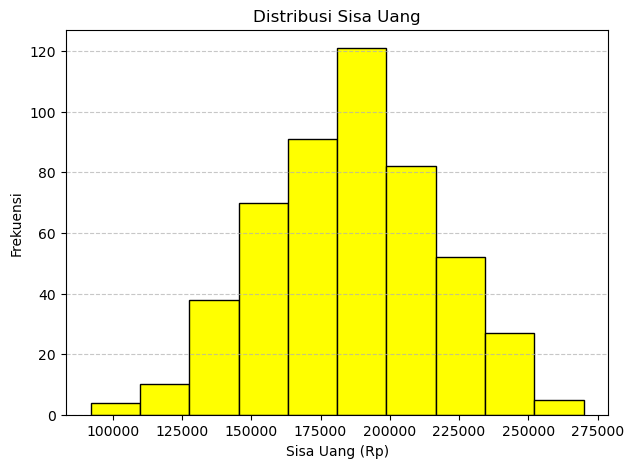

In [148]:
import matplotlib.pyplot as plt

# Histogram sisa uang
plt.figure(figsize=(7,5))
plt.hist(sisa, bins=10, color="yellow", edgecolor="black")
plt.xlabel("Sisa Uang (Rp)")
plt.ylabel("Frekuensi")
plt.title("Distribusi Sisa Uang")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


Histogram menunjukkan bahwa sebagian besar responden memiliki sisa uang bulanan antara Rp150.000 hingga Rp200.000, terlihat dari batang dengan tinggi tertinggi pada rentang tersebut dengan frekuensi lebih dari 100. Bentuk distribusi data mendekati pola normal, artinya nilai sisa uang yang terlalu rendah (di bawah Rp120.000) atau terlalu tinggi (di atas Rp250.000) tidak terlalu banyak. Hal ini berarti kebanyakan orang memiliki kondisi ekonomi yang cukup stabil, tidak terlalu boros tetapi juga tidak menyisihkan uang terlalu banyak. Puncak dari distribusi ini bisa jadi patokan untuk mengetahui nilai sisa uang yang umum atau sering terjadi di antara responden.

# CHAT GPT
1. buatkan codingan untuk menampilkan histogram sisa uang
-> Keterangan: Histogram → menunjukkan distribusi sisa uang.

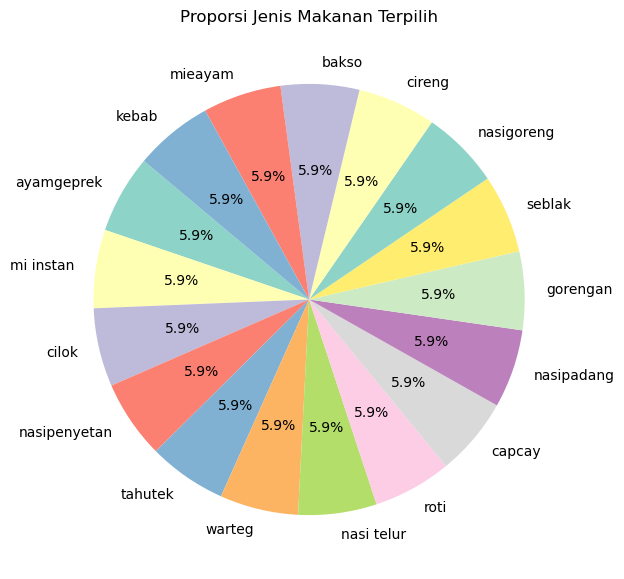

In [150]:
# Hitung jumlah tiap jenis makanan yang terpilih
jenis_count = makan["makanan"].value_counts()

# Pie chart
plt.figure(figsize=(7,7))
plt.pie(
    jenis_count,
    labels=jenis_count.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=plt.cm.Set3.colors
)
plt.title("Proporsi Jenis Makanan Terpilih")
plt.show()


Pada kode diatas digunakan untuk melihat pembagian makanan yang dipilih dalam simulasi. Dengan pie chart diatas dapat dilihat, pembagian makanan selama sebulan adlah rata dengan angka 5,9%

# CHAT GPT
1. buatkan codingan untuk menampilkan pie chart jenis makanan terpilih.
-> Keterangan: Pie chart → menampilkan proporsi makanan berdasarkan kolom jenis pada dataframe makan.

2. berdasarkan makanan aja apakah masuk akal?
-> Iyaa, masuk akal kok 👍 Kalau dataset kamu belum punya kategori/jenis, maka pie chart berdasarkan makanan masih bisa dipakai untuk melihat makanan mana yang paling sering dipilih.
Itu tetap valid karena tujuannya menggambarkan proporsi pemilihan.Bedanya: Berdasarkan makanan → tiap nama makanan muncul (misalnya Nasi Goreng 40%, Ayam Bakar 20%, dll). Berdasarkan jenis → dikelompokkan (misalnya Karbohidrat 50%, Protein 30%, Sayur 20%). Kalau kamu memang belum bikin kategori, lebih simpel langsung pakai nama makanan.

In [157]:
# Group berdasarkan kategori bosan
group_bosan = makan.groupby(makan["bosan"] >= 0.5)["makanan"].apply(list)

# Rename index biar lebih jelas
group_bosan.index = ["Tidak Cepat Bosan", "Cepat Bosan"]

print("=== Kelompok Bosan ===")
for kategori, daftar in group_bosan.items():
    print(f"\n{kategori}:")
    for m in daftar:
        print(f" - {m}")


# Group berdasarkan kategori sehat
group_sehat = makan.groupby(makan["sehat"] >= 0.4)["makanan"].apply(list)

# Rename index biar lebih jelas
group_sehat.index = ["Kurang Sehat", "Sehat"]

print("\n=== Kelompok Sehat ===")
for kategori, daftar in group_sehat.items():
    print(f"\n{kategori}:")
    for m in daftar:
        print(f" - {m}")


=== Kelompok Bosan ===

Tidak Cepat Bosan:
 - ayamgeprek
 - mieayam
 - bakso
 - capcay
 - mi instan
 - roti
 - warteg

Cepat Bosan:
 - nasipadang
 - cireng
 - nasigoreng
 - seblak
 - gorengan
 - nasi telur
 - tahutek
 - nasipenyetan
 - cilok
 - kebab

=== Kelompok Sehat ===

Kurang Sehat:
 - bakso
 - seblak
 - gorengan
 - mi instan
 - roti

Sehat:
 - ayamgeprek
 - nasipadang
 - mieayam
 - cireng
 - nasigoreng
 - capcay
 - nasi telur
 - warteg
 - tahutek
 - nasipenyetan
 - cilok
 - kebab


Kode diatas digunakan untuk mengelompokkan makanan mana saja yang membuat tidak cepat bosan dan cepat bosan, serta saya menambahkan mengelompokkan makanan yang sehat. 

# CHAT GPT
1. apakah bisa mengelompokkan dengan group by mana makanan yang membuat bosan dan tidak berdasarkan rate bosan? dan apakah bisa mengelompokkan mana makanan sehat dan tidak sehat?
-> Ahh sip, paham sekarang 👌 Kalau maksudmu bukan bikin kolom kategori saja, tapi benar-benar dikelompokkan (group by) berdasarkan kategori bosan / sehat, maka bisa dibuat seperti ini. Dengan cara ini, makanan otomatis masuk ke grup sesuai dengan nilai bosan dan sehat-nya. 

2. yang tidak sehat mengapa tidak muncul?
-> Oke, aku jelasin dulu kenapa makanan “tidak sehat” tidak muncul ya 👇 Di kode grouping ini. artinya:
makan["sehat"] >= 0.5 → nilai True (sehat) atau False (kurang sehat). Kalau di datamu ternyata semua makanan punya skor sehat ≥ 0.5, maka kategori False (Kurang Sehat) memang kosong → otomatis tidak muncul.